                        Corelation Analysis

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

In [5]:
import sys, os
from dotenv import load_dotenv

# Resolve project root and add src to path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
load_dotenv(os.path.join(PROJECT_ROOT, '.env'))
API_KEY = os.getenv('ALPHA_VANTAGE_API_KEY', '')

sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

DATA_DIR   = os.path.join(PROJECT_ROOT, 'data')
NEWS_CACHE  = os.path.join(DATA_DIR, 'news_cache.csv')
STOCK_CACHE = os.path.join(DATA_DIR, 'stock_cache.csv')
os.makedirs(DATA_DIR, exist_ok=True)

TICKERS = {
    'AAPL': 'Apple',
    'AMZN': 'Amazon',
    'GOOGL': 'Google',
    'META': 'Meta',
    'MSFT': 'Microsoft',
    'NVDA': 'Nvidia',
    'TSLA': 'Tesla',
}
print("Setup complete. Project root:", PROJECT_ROOT)


Setup complete. Project root: c:\Users\Administrator\Desktop\Financial-News-Sentiment-Stock-Market-Correlation-Analysis-main


In [6]:
from data_fetcher import fetch_news, fetch_stock_data_yfinance

# --- Stock data ---
if os.path.exists(STOCK_CACHE):
    print("Loading stock data from cache...")
    stock_df = pd.read_csv(STOCK_CACHE)
else:
    print("Fetching stock data via yfinance...")
    stock_df = fetch_stock_data_yfinance(TICKERS, period='6mo')
    stock_df.to_csv(STOCK_CACHE, index=False)
    print("  Saved to", STOCK_CACHE)

# --- News data ---
if os.path.exists(NEWS_CACHE):
    print("Loading news data from cache...")
    news_df = pd.read_csv(NEWS_CACHE)
else:
    print("Fetching news from Alpha Vantage (may fallback to sample data)...")
    fallback_dates = sorted(stock_df['date'].dropna().unique().tolist())
    news_df = fetch_news(list(TICKERS.keys()), API_KEY,
                         tickers_map=TICKERS, fallback_dates=fallback_dates)
    news_df.to_csv(NEWS_CACHE, index=False)
    print("  Saved to", NEWS_CACHE)

print(f"news_df: {news_df.shape}  |  stock_df: {stock_df.shape}")


Loading stock data from cache...
Loading news data from cache...
news_df: (1746, 3)  |  stock_df: (868, 7)


In [7]:
# stock_df already has a 'Company' column added by the fetcher
# Build per-company dict for later per-ticker correlation section
stock_data = {company: grp.copy() for company, grp in stock_df.groupby('Company')}
print("Companies loaded:", list(stock_data.keys()))


Companies loaded: ['Amazon', 'Apple', 'Google', 'Meta', 'Microsoft', 'Nvidia', 'Tesla']


In [8]:
news_df.head()

,headline,date,stock
0,Apple CEO outlines growth strategy at investor...,2025-10-27,AAPL
1,Apple beats revenue estimates for the third co...,2025-10-27,AAPL
2,Amazon announces share buyback program worth $...,2025-10-27,AMZN
3,Institutional investors increase stake in Amazon,2025-10-27,AMZN
4,Amazon CEO outlines growth strategy at investo...,2025-10-27,AMZN


In [9]:
stock_df.head()

,date,Open,High,Low,Close,Volume,Company
0,2025-10-27,264.376098,268.608022,264.146525,268.298615,44888200,Apple
1,2025-10-28,268.478260,269.376572,267.639862,268.488251,41534800,Apple
2,2025-10-29,268.767706,270.893658,266.601821,269.186920,51086700,Apple
3,2025-10-30,271.472541,273.618475,267.969239,270.883667,69886500,Apple
4,2025-10-31,276.463053,276.792443,268.647962,269.855652,86167100,Apple


In [10]:
news_df.shape, stock_df.shape

((1746, 3), (868, 7))

In [11]:
# Drop unnamed index column if it exists (only present in older CSV exports)
if news_df.columns[0].startswith('Unnamed'):
    news_df = news_df.drop(news_df.columns[0], axis=1)
news_df.head(2)


,headline,date,stock
0,Apple CEO outlines growth strategy at investor...,2025-10-27,AAPL
1,Apple beats revenue estimates for the third co...,2025-10-27,AAPL


Load and Normalize Data:

Load Datasets:

In [12]:
# Convert 'date' columns to datetime (both already lowercase 'date')
news_df['date']  = pd.to_datetime(news_df['date'],  errors='coerce').dt.tz_localize(None)
stock_df['date'] = pd.to_datetime(stock_df['date'], errors='coerce').dt.tz_localize(None)


In [ ]:
news_df.head(1)

,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54,A


In [ ]:
stock_df.head(1)

,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Company
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098943,469033600,0.0,0.0,Apple


In [ ]:
news_df.columns, stock_df.columns

(Index(['headline', 'url', 'publisher', 'date', 'stock'], dtype='object'),
 Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
        'Dividends', 'Stock Splits', 'Company'],
       dtype='object'))

In [13]:
# Both DataFrames already use lowercase 'date' — no rename needed
print("news_df columns: ", news_df.columns.tolist())
print("stock_df columns:", stock_df.columns.tolist())


news_df columns:  ['headline', 'date', 'stock']
stock_df columns: ['date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Company']


In [14]:
# Format 'date' column to 'yyyy-mm-dd' format
news_df['date'] = news_df['date'].dt.strftime('%Y-%m-%d')
stock_df['date'] = stock_df['date'].dt.strftime('%Y-%m-%d')

In [ ]:
news_df.head(2)

,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03,A


In [ ]:
stock_df.head(2)

,date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Company
0,1980-12-12,0.128348,0.128906,0.128348,0.128348,0.098943,469033600,0.0,0.0,Apple
1,1980-12-15,0.122210,0.122210,0.121652,0.121652,0.093781,175884800,0.0,0.0,Apple


In [15]:
# Merge the two DataFrames on the 'date' column
merged_df = pd.merge(news_df, stock_df, on='date')
merged_df.head()

,headline,date,stock,Open,High,Low,Close,Volume,Company
0,Apple CEO outlines growth strategy at investor...,2025-10-27,AAPL,264.376098,268.608022,264.146525,268.298615,44888200,Apple
1,Apple CEO outlines growth strategy at investor...,2025-10-27,AAPL,227.660004,228.399994,225.539993,226.970001,38267000,Amazon
2,Apple CEO outlines growth strategy at investor...,2025-10-27,AAPL,264.460719,269.773508,263.921443,268.904663,35235200,Google
3,Apple CEO outlines growth strategy at investor...,2025-10-27,AAPL,748.478138,754.488106,746.761040,749.566345,11321100,Meta
4,Apple CEO outlines growth strategy at investor...,2025-10-27,AAPL,529.577903,532.366296,526.819354,529.318970,18734700,Microsoft


In [16]:
merged_df.shape

(12222, 9)

In [17]:
merged_df.isnull().sum()

headline    0
date        0
stock       0
Open        0
High        0
Low         0
Close       0
Volume      0
Company     0
dtype: int64

In [ ]:
merged_df.duplicated().sum()

0

In [ ]:
merged_df.describe()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
count,384804.000000,384804.000000,384804.000000,384804.000000,384804.000000,3.848040e+05,384804.000000,384804.000000
mean,76.167291,77.335021,75.128625,76.265298,74.980180,1.551286e+08,0.001746,0.000099
std,62.557257,63.479679,61.735837,62.655100,61.898823,2.029620e+08,0.025952,0.020775
min,0.287250,0.290750,0.278750,0.284500,0.260951,1.584340e+05,0.000000,0.000000
25%,24.754999,25.124666,24.166668,24.723499,23.328667,3.227350e+07,0.000000,0.000000
50%,61.566666,62.957500,60.610668,61.238499,60.253620,7.586440e+07,0.000000,0.000000
75%,116.500504,117.872498,115.300003,115.889999,115.799500,1.896200e+08,0.000000,0.000000
max,240.960007,241.210007,235.279999,238.669998,238.180557,3.692928e+09,0.510000,7.000000


In [18]:
def analyze_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

In [19]:
merged_df['sentiment'] = merged_df['headline'].apply(analyze_sentiment)

In [ ]:
# Save the sentimented dataset to a CSV file
merged_df.to_csv('sentimented_df.csv', index=False)

In [ ]:
merged_df.head()

,headline,url,publisher,date,stock,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Company,sentiment
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05,A,80.837502,82.937500,80.807503,82.875000,80.843407,137250400,0.0,0.0,Apple,0.0
1,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05,A,122.225502,124.432503,121.856499,124.150002,124.150002,66128000,0.0,0.0,Amazon,0.0
2,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05,A,70.658501,72.252502,70.300003,71.919502,71.837753,34698000,0.0,0.0,Google,0.0
3,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05,A,226.710007,231.350006,225.309998,230.770004,230.296753,16750400,0.0,0.0,Meta,0.0
4,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05,A,182.619995,187.729996,182.009995,187.199997,180.403564,39893600,0.0,0.0,Microsoft,0.0


In [20]:
# Calculate daily stock returns
merged_df['Daily Return'] = merged_df['Close'].pct_change() * 100

In [ ]:
merged_df.head(2)

,headline,url,publisher,date,stock,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits,Company,sentiment,Daily Return
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05,A,80.837502,82.937500,80.807503,82.875000,80.843407,137250400,0.0,0.0,Apple,0.0,NaN
1,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05,A,122.225502,124.432503,121.856499,124.150002,124.150002,66128000,0.0,0.0,Amazon,0.0,49.803923


In [21]:
# Aggregate sentiments by date
daily_sentiment = merged_df.groupby('date')['sentiment'].mean().reset_index()
daily_sentiment.columns = ['date', 'Average Sentiment']

In [ ]:
daily_sentiment.head()

,date,Average Sentiment
0,2011-04-27,0.000000
1,2011-04-28,0.068182
2,2011-04-29,0.166667
3,2011-05-02,-0.009259
4,2011-05-03,0.000000


In [22]:
# Merge sentiment data with stock data
daily_df = pd.merge(merged_df[['date', 'Daily Return']], daily_sentiment, on='date', how='inner')

In [ ]:
daily_df.head()

,date,Daily Return,Average Sentiment
0,2020-06-05,NaN,0.110735
1,2020-06-05,49.803923,0.110735
2,2020-06-05,-42.070478,0.110735
3,2020-06-05,220.872638,0.110735
4,2020-06-05,-18.880273,0.110735


In [23]:
# Calculate correlation
correlation = daily_df[['Average Sentiment', 'Daily Return']].corr().iloc[0, 1]
print(f'Pearson correlation coefficient: {correlation}')

Pearson correlation coefficient: -0.002561240720280019


In [24]:
from datetime import datetime

# Ensure date columns are string format for merging
news_df_dated  = news_df.copy()
news_df_dated['date']  = pd.to_datetime(news_df_dated['date'],  errors='coerce').dt.strftime('%Y-%m-%d')

# Filter news to trading days only (dates that exist in stock data)
all_trading_dates = set(stock_df['date'].dropna().astype(str))
news_df_dated = news_df_dated[news_df_dated['date'].isin(all_trading_dates)]

# Check for missing dates per company
for company, df in stock_data.items():
    stock_dates = set(pd.to_datetime(df['date'], errors='coerce').dt.strftime('%Y-%m-%d').dropna())
    missing = set(news_df_dated['date']) - stock_dates
    if missing:
        print(f"Missing dates in {company}: {len(missing)} dates")

print("Stock data sample (Apple):")
print(list(stock_data.values())[0].head())


Stock data sample (Apple):
           date        Open        High         Low       Close     Volume  \
124  2025-10-27  227.660004  228.399994  225.539993  226.970001   38267000   
125  2025-10-28  228.220001  231.490005  226.210007  229.250000   47100000   
126  2025-10-29  231.669998  232.820007  227.759995  230.300003   52036200   
127  2025-10-30  227.059998  228.440002  222.750000  222.860001  102252900   
128  2025-10-31  250.100006  250.500000  243.979996  244.220001  166340800   

    Company  
124  Amazon  
125  Amazon  
126  Amazon  
127  Amazon  
128  Amazon  


                 Stock Movement

In [25]:
# Compute daily returns per company
for company, df in stock_data.items():
    df['daily_return'] = df['Close'].pct_change()
    df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.strftime('%Y-%m-%d')
    print(f"Daily Returns for {company}:")
    print(df[['date', 'Close', 'daily_return']].head(5).to_string(index=False))
    print()


Daily Returns for Amazon:
      date      Close  daily_return
2025-10-27 226.970001           NaN
2025-10-28 229.250000      0.010045
2025-10-29 230.300003      0.004580
2025-10-30 222.860001     -0.032306
2025-10-31 244.220001      0.095845

Daily Returns for Apple:
      date      Close  daily_return
2025-10-27 268.298615           NaN
2025-10-28 268.488251      0.000707
2025-10-29 269.186920      0.002602
2025-10-30 270.883667      0.006303
2025-10-31 269.855652     -0.003795

Daily Returns for Google:
      date      Close  daily_return
2025-10-27 268.904663           NaN
2025-10-28 267.107147     -0.006685
2025-10-29 274.197510      0.026545
2025-10-30 281.098145      0.025167
2025-10-31 280.808502     -0.001030

Daily Returns for Meta:
      date      Close  daily_return
2025-10-27 749.566345           NaN
2025-10-28 750.185364      0.000826
2025-10-29 750.414917      0.000306
2025-10-30 665.357239     -0.113348
2025-10-31 647.267456     -0.027188

Daily Returns for Microsoft:
  

 Visualizations

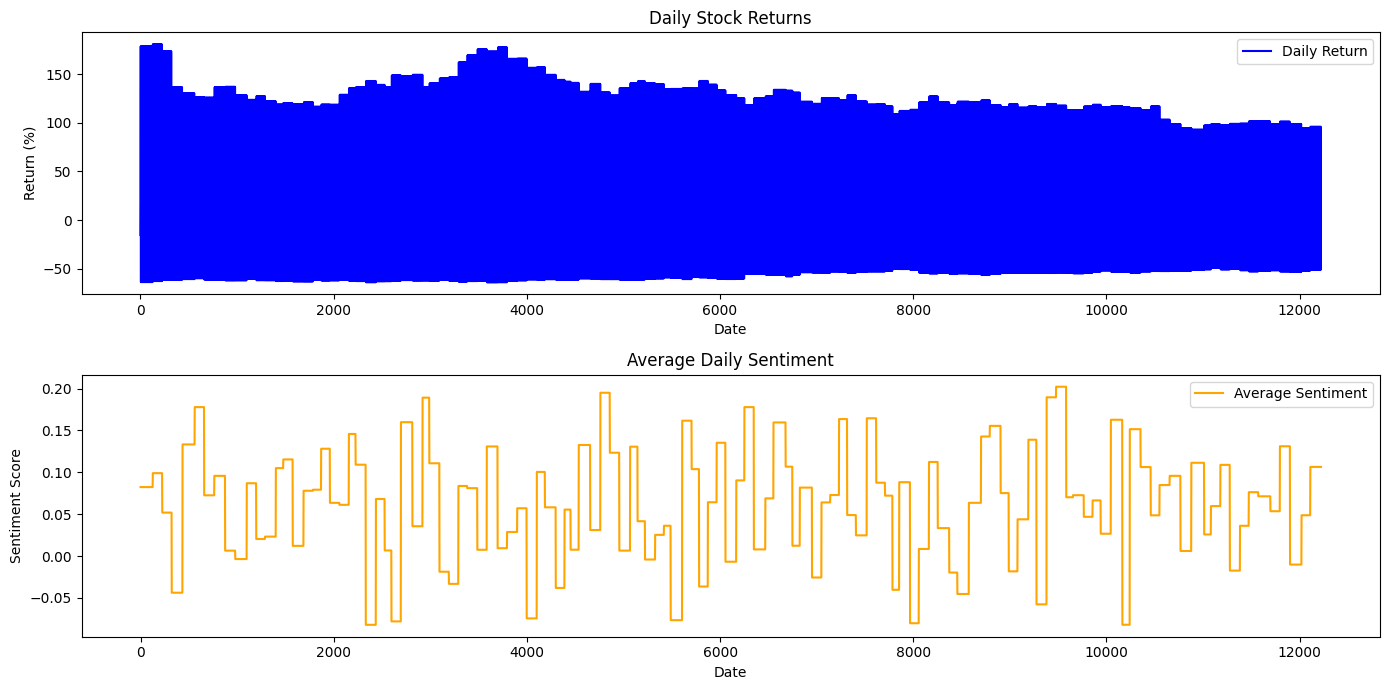

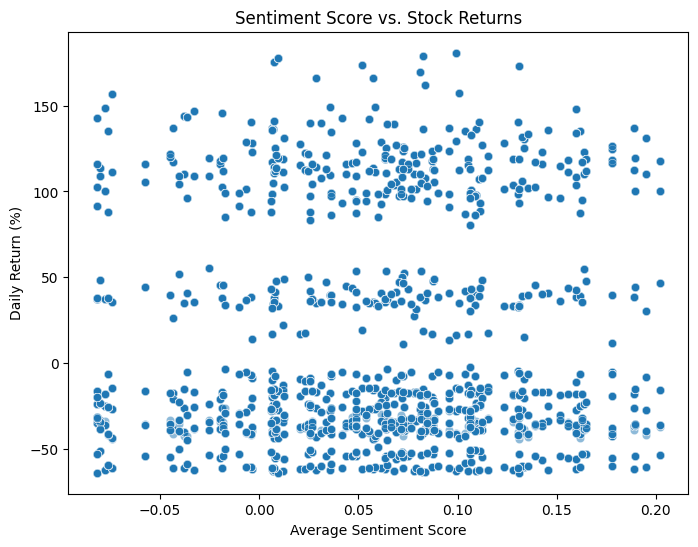

In [26]:
# Plot daily returns and average sentiment
plt.figure(figsize=(14, 7))

# Plot stock returns
plt.subplot(2, 1, 1)
plt.plot(daily_df.index, daily_df['Daily Return'], label='Daily Return', color='blue')
plt.title('Daily Stock Returns')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.legend()

# Plot average sentiment
plt.subplot(2, 1, 2)
plt.plot(daily_df.index, daily_df['Average Sentiment'], label='Average Sentiment', color='orange')
plt.title('Average Daily Sentiment')
plt.xlabel('Date')
plt.ylabel('Sentiment Score')
plt.legend()

plt.tight_layout()
plt.show()

# Scatter plot to visualize correlation
plt.figure(figsize=(8, 6))
sns.scatterplot(data=daily_df, x='Average Sentiment', y='Daily Return', alpha=0.5)
plt.title('Sentiment Score vs. Stock Returns')
plt.xlabel('Average Sentiment Score')
plt.ylabel('Daily Return (%)')
plt.show()

In [ ]:
from textblob import TextBlob
import nltk
nltk.download('punkt')

# 2.1 Perform Sentiment Analysis
def get_sentiment(headline):
    analysis = TextBlob(headline)
    # Categorize sentiment as positive, negative, or neutral
    if analysis.sentiment.polarity > 0:
        return 1
    elif analysis.sentiment.polarity < 0:
        return -1
    else:
        return 0

news_df['sentiment'] = news_df['headline'].apply(get_sentiment)

# 2.2 Aggregate Sentiment Scores by Date
aggregated_sentiment = news_df.groupby('date')['sentiment'].mean().reset_index()
aggregated_sentiment.columns = ['date', 'avg_sentiment']

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Dagi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Pearson Correlation for Amazon: -0.0235


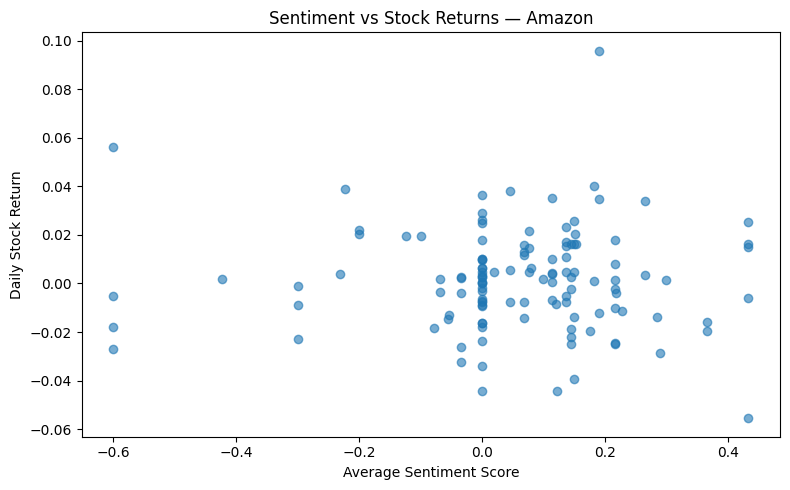

Pearson Correlation for Apple: -0.1335


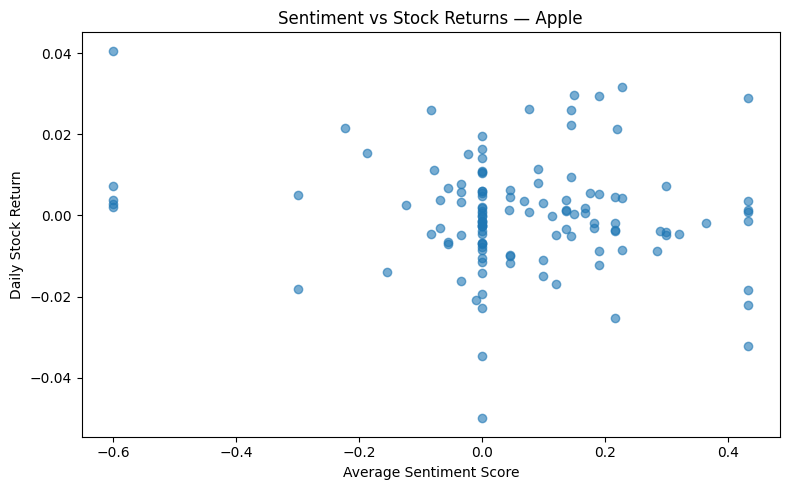

Pearson Correlation for Google: 0.0124


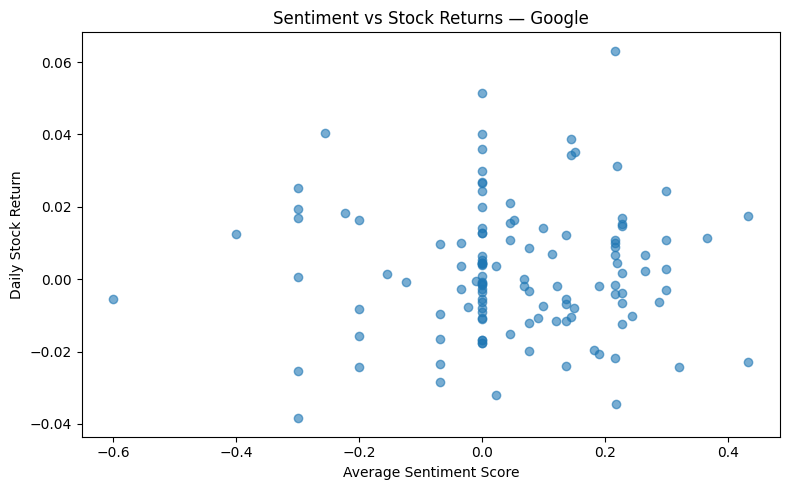

Pearson Correlation for Meta: -0.0359


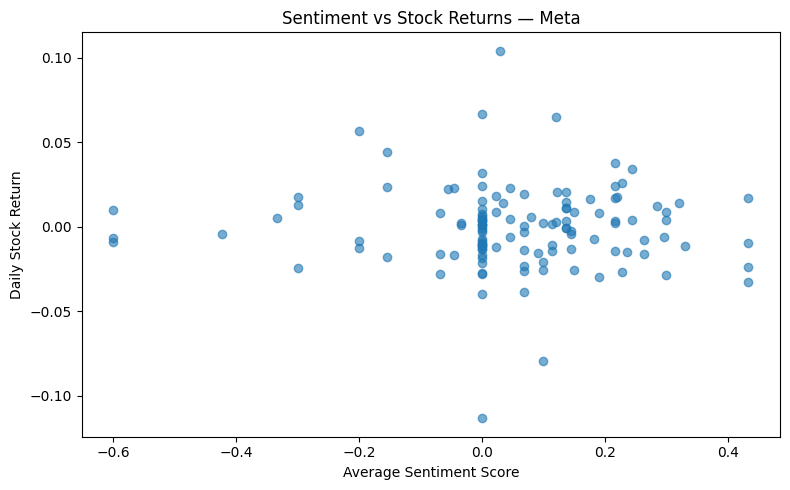

Pearson Correlation for Microsoft: 0.0136


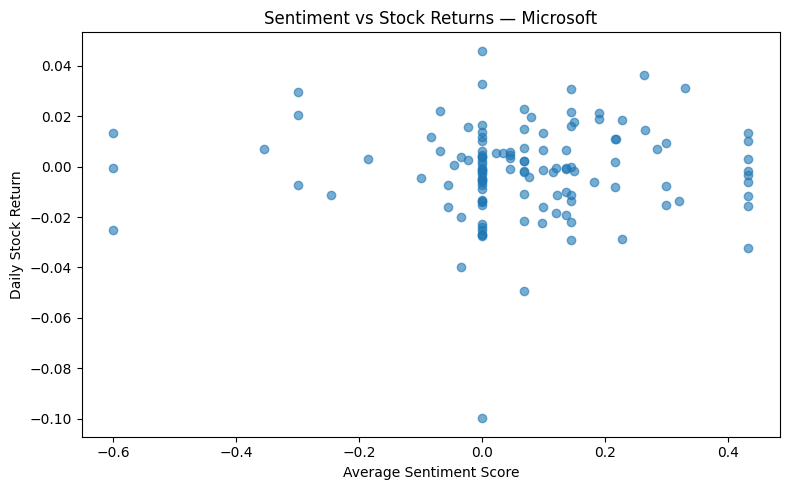

Pearson Correlation for Nvidia: -0.0349


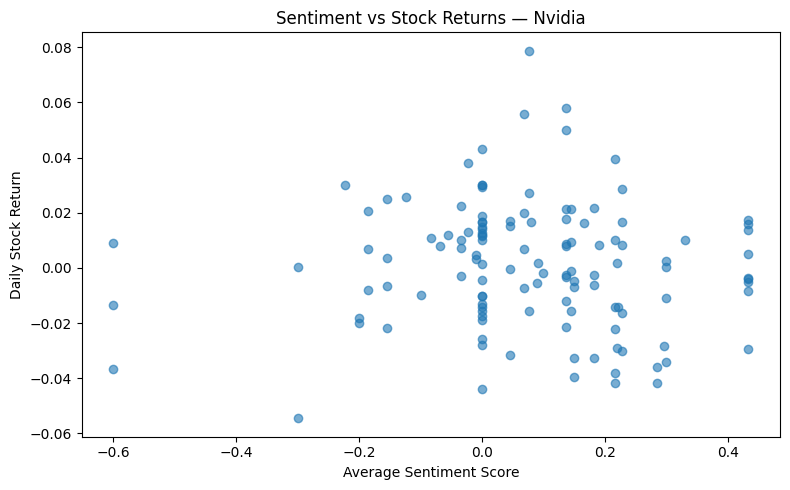

Pearson Correlation for Tesla: -0.1754


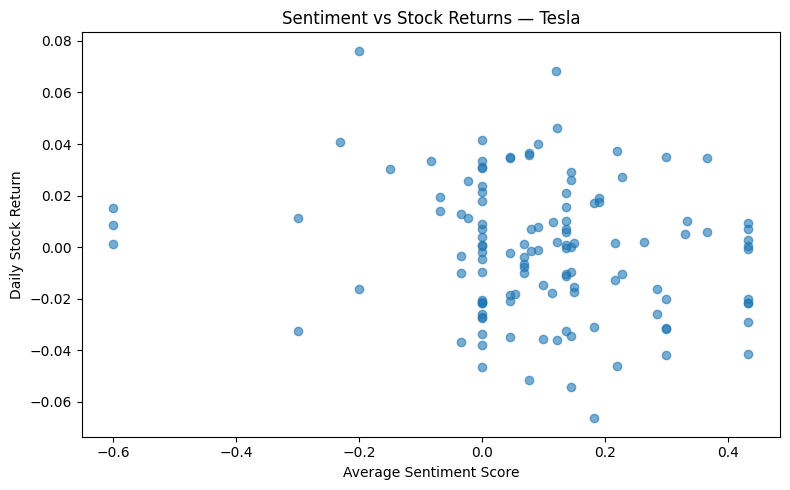

In [27]:
import matplotlib.pyplot as plt

# Per-company Pearson correlation between sentiment and daily return
for company, df in stock_data.items():
    ticker = [k for k, v in TICKERS.items() if v == company]
    if not ticker:
        continue
    company_news = news_df_dated[news_df_dated['stock'] == ticker[0]].copy()
    if company_news.empty:
        print(f"No news for {company}, skipping.")
        continue

    company_news['sentiment'] = company_news['headline'].apply(
        lambda t: TextBlob(t).sentiment.polarity
    )
    agg = company_news.groupby('date')['sentiment'].mean().reset_index()
    agg.columns = ['date', 'avg_sentiment']

    merged = pd.merge(agg, df[['date', 'daily_return']], on='date')
    if merged.shape[0] < 2:
        print(f"{company}: not enough overlapping dates to correlate.")
        continue

    correlation = merged['avg_sentiment'].corr(merged['daily_return'])
    print(f"Pearson Correlation for {company}: {correlation:.4f}")

    plt.figure(figsize=(8, 5))
    plt.scatter(merged['avg_sentiment'], merged['daily_return'], alpha=0.6)
    plt.title(f'Sentiment vs Stock Returns — {company}')
    plt.xlabel('Average Sentiment Score')
    plt.ylabel('Daily Stock Return')
    plt.tight_layout()
    plt.show()
